In [38]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv

In [39]:
load_dotenv()

True

In [40]:
# use different llms for different tasks as per their capability in the real life project
generator_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)
evaluator_llm = ChatGroq(model="llama-3.3-70b-versatile")
optimizer_llm = ChatGroq(model="llama-3.1-8b-instant")

In [41]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [42]:
structured_evaluator_llm =evaluator_llm.with_structured_output(TweetEvaluation) 

In [43]:
# state
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int        # to avoid infinite loops

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [ ]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are an funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages).content
    return {'tweet': response, 'tweet_history': [response]}

In [59]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)
    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [60]:
def optimize_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [61]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [62]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_imrovement': 'optimize'})
graph.add_edge('optimize', 'evaluate')    # creating loop

workflow = graph.compile()

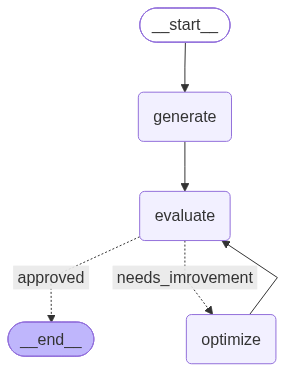

In [63]:
workflow

In [64]:
initial_state = {
    'topic': 'indian railways',
    'iteration': 1,
    'max_iteration': 5
}

workflow.invoke(initial_state)

{'topic': 'indian railways',
 'tweet': '"Just boarded the Indian Railways and I\'m pretty sure I\'ve found the secret to meditation - the constant sound of the horn, the aroma of stale samosas, and the thrill of possibly getting a seat in the next 5 hours #IndianRailways #TrainLife #SamosaSerenity"',
 'evaluation': 'approved',
 'feedback': "This tweet is a masterclass in humor, originality, and punchiness. The use of sensory details like the 'constant sound of the horn' and 'aroma of stale samosas' effectively transports the reader to the scene, making the joke more relatable and engaging. The tweet's unique perspective on finding meditation in a chaotic environment like Indian Railways is fresh and clever. The hashtags #IndianRailways, #TrainLife, and #SamosaSerenity add a touch of whimsy and help increase the tweet's virality potential. The only potential improvement could be to make the language even more concise, but overall, the tweet is well-formed, funny, and scroll-stopping.",
